## Contact energy

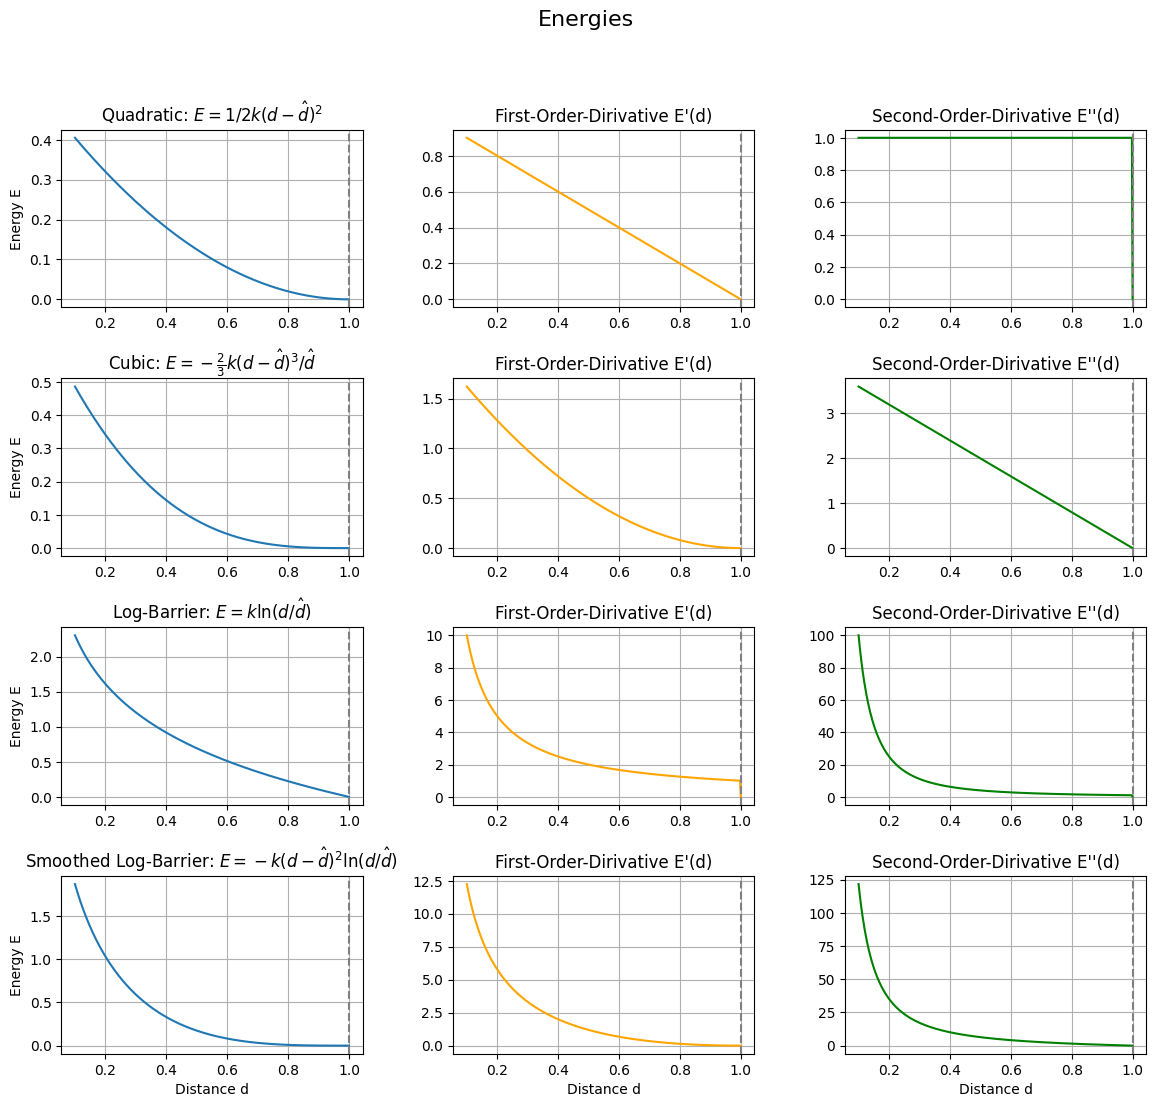

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

k = 1.0
d_hat = 1.0
d = jnp.linspace(0.1, 1.0, 400)

# ----------------------
# Energy functions
# ----------------------

def E_quadratic(d, k, d_hat):
    return 0.5 * k * (d - d_hat)**2

def E_cubic(d, k, d_hat):
    return -2/3 * k * (d - d_hat)**3 / d_hat

def E_log(d, k, d_hat):
    return -k * jnp.log(d / d_hat)

def E_smooth(d, k, d_hat):
    return -k * (d - d_hat)**2 * jnp.log(d / d_hat)

def truncated(E_func):
    def E_trunc(d, k, d_hat):
        raw_E = E_func(d, k, d_hat)
        return jnp.where(d < d_hat, raw_E, 0.0)
    return E_trunc
energy_funcs = [
    truncated(E_quadratic),
    truncated(E_cubic),
    truncated(E_log),
    truncated(E_smooth),
]
titles = [
    "Quadratic: $E = 1/2 k (d - \\hat{d})^2$",
    "Cubic: $E = -\\frac{2}{3} k (d - \\hat{d})^3 / \\hat{d}$",
    "Log-Barrier: $E = k \\ln(d / \\hat{d})$",
    "Smoothed Log-Barrier: $E = -k (d - \\hat{d})^2 \\ln(d / \\hat{d})$"
]

# ----------------------
# Automatic differentiation
# ----------------------


def compute_energy_and_derivatives(E_func, d_values):
    # First derivative
    E_prime = jax.grad(lambda x: E_func(x, k, d_hat))
    # Second derivative
    E_double = jax.grad(lambda x: E_prime(x))
    
    E_vals = jax.vmap(lambda x: E_func(x, k, d_hat))(d_values)
    E1_vals = jax.vmap(E_prime)(d_values)
    E2_vals = jax.vmap(E_double)(d_values)
    return E_vals, E1_vals, E2_vals


# ----------------------
# Plotting
# ----------------------
fig, axs = plt.subplots(4, 3, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, E_func in enumerate(energy_funcs):
    E_vals, E1_vals, E2_vals = compute_energy_and_derivatives(E_func, d)
    
    # E(d)
    axs[i, 0].plot(d, E_vals)
    axs[i, 0].axvline(d_hat, color='gray', linestyle='--')
    axs[i, 0].set_title(titles[i])
    axs[i, 0].set_ylabel("Energy E")
    axs[i, 0].grid(True)
    
    # E'(d)
    axs[i, 1].plot(d, -E1_vals, color='orange')
    axs[i, 1].axvline(d_hat, color='gray', linestyle='--')
    axs[i, 1].set_title("First-Order-Dirivative E'(d)")
    axs[i, 1].grid(True)
    
    # E''(d)
    axs[i, 2].plot(d, E2_vals, color='green')
    axs[i, 2].axvline(d_hat, color='gray', linestyle='--')
    axs[i, 2].set_title("Second-Order-Dirivative E''(d)")
    axs[i, 2].grid(True)

for ax in axs[-1, :]:
    ax.set_xlabel("Distance d")

plt.suptitle("Energies", fontsize=16)
plt.show()


In [2]:
# float dBdD;
# float ddBddD;
# float avg_area  = 1.0f;
# float kappa     = 1.0f;
# float thickness = 0.0f;
# float d_hat     = 0.001f;
# float d         = 0.0005f;


In [3]:
k = 1.0      # kappa
d_hat = 1.0  # reference distance
d_val = 0.5

import jax.numpy as jnp

E_vals, E1_vals, E2_vals = compute_energy_and_derivatives(E_smooth, jnp.array([d_val]))
E = float(E_vals[0])
E1 = float(E1_vals[0])
E2 = float(E2_vals[0])
print(f"d = {d_val}")
print(f"E (Smoothed Log-Barrier) = {E:.12e}")
print(f"E' = {E1:.12e}")
print(f"E'' = {E2:.12e}")

# E = -k*(d-d_hat)**2 * ln(d/d_hat)  => 约 0.17328679513998632
# E' = -k*(2*(d-d_hat)*ln(d/d_hat) + (d-d_hat)**2 / d) => 约 -1.1931471805599453
# E'' = -k*(2*ln(d/d_hat) + 4*(d-d_hat)/d - (d-d_hat)**2 / d**2) => 约 6.386294361119891


d = 0.5
E (Smoothed Log-Barrier) = 1.732867956161e-01
E' = -1.193147182465e+00
E'' = 6.386294364929e+00
